# D2Q9 Taylor-Green Validation

This notebook validates the periodic D2Q9 Taylor-Green benchmark at controlled viscous decay. The focus is convergence and diagnostic quality before moving to quantum emulation.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt

from pq_cfd import d2q9_validation_cases, run_d2q9_validation, write_d2q9_validation_csv

In [2]:
output_dir = project_root / ".cache" / "benchmarks"
output_dir.mkdir(parents=True, exist_ok=True)

cases = d2q9_validation_cases(amplitude=0.03)
records = run_d2q9_validation(cases)
csv_path = write_d2q9_validation_csv(records, output_dir / "d2q9_validation.csv")

print(f"cases: {len(records)}")
print(f"CSV output: {csv_path}")
print(f"stable cases: {sum(record.stable for record in records)} / {len(records)}")

cases: 12
CSV output: c:\Users\NishchayVORA\Documents\PQ_CFD\.cache\benchmarks\d2q9_validation.csv
stable cases: 12 / 12


The timestep count is chosen from a fixed target exponent `nu * (kx^2 + ky^2) * steps`, so each grid is compared after roughly the same analytic velocity decay. That makes the convergence plots more meaningful than simply using `steps = nx` for every case.

In [3]:
def plot_metric(metric, ylabel, title, *, log_y=True):
    fig, ax = plt.subplots(figsize=(7, 4))
    for tau in sorted({record.tau for record in records}):
        subset = sorted(
            [record for record in records if record.tau == tau],
            key=lambda record: record.grid_points,
        )
        x = [record.grid_points for record in subset]
        y = [max(getattr(record, metric), 1e-18) for record in subset]
        ax.plot(x, y, marker="o", label=f"tau={tau}")
    ax.set_xscale("log", base=2)
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel("grid points")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig, ax

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Kinetic energy error'}, xlabel='grid points', ylabel='relative kinetic energy error'>)

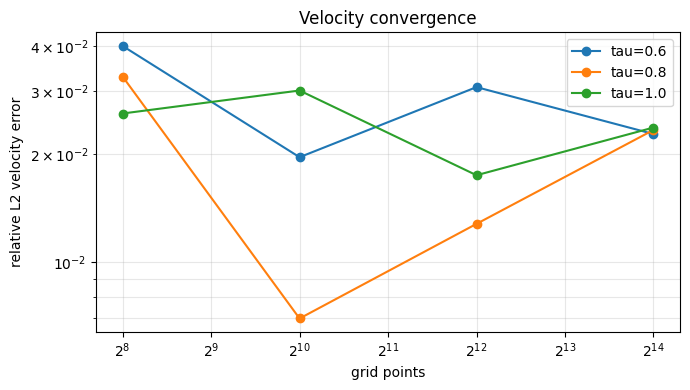

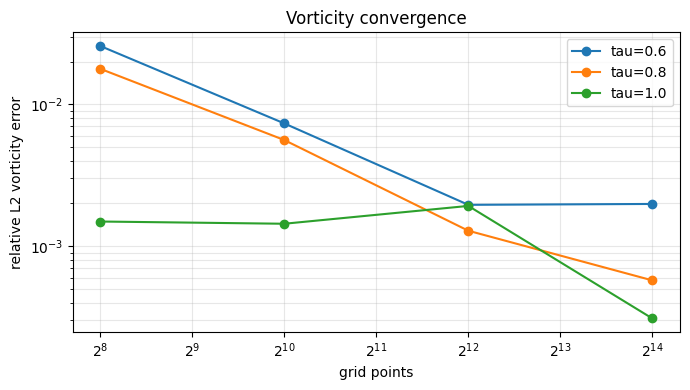

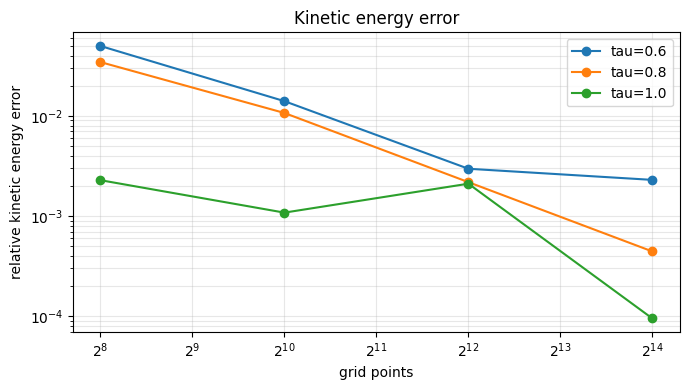

In [4]:
plot_metric("velocity_relative_l2_error", "relative L2 velocity error", "Velocity convergence")
plot_metric("vorticity_relative_l2_error", "relative L2 vorticity error", "Vorticity convergence")
plot_metric("kinetic_energy_relative_error", "relative kinetic energy error", "Kinetic energy error")

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Runtime scaling'}, xlabel='grid points', ylabel='runtime (s)'>)

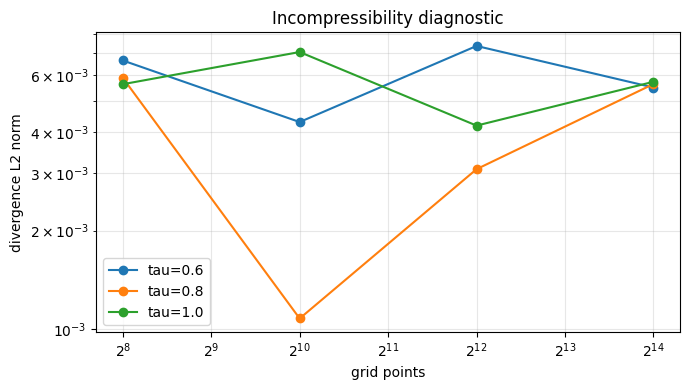

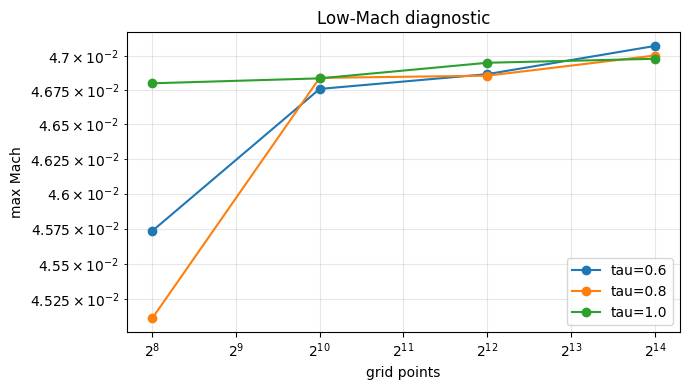

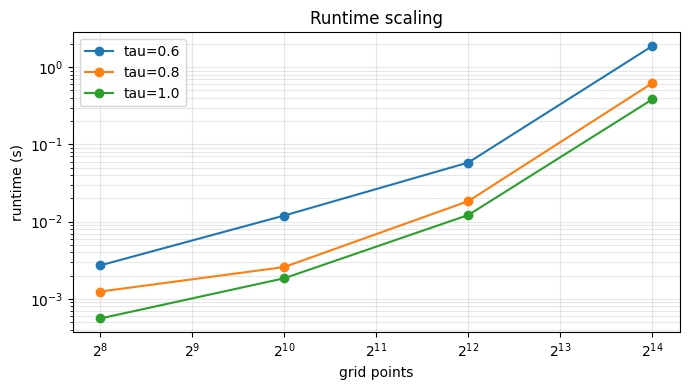

In [5]:
plot_metric("divergence_l2_norm", "divergence L2 norm", "Incompressibility diagnostic")
plot_metric("max_mach", "max Mach", "Low-Mach diagnostic")
plot_metric("runtime_seconds", "runtime (s)", "Runtime scaling")

## Analysis of Current Validation Outputs

The validation run is reassuring on stability: all tested Taylor-Green cases remain low-Mach, preserve mass to roundoff, keep density positive, and produce finite diagnostics. The maximum Mach number is well below the conservative `0.1` cutoff, so the simulations are inside the intended weakly compressible regime.

The accuracy picture is more nuanced. Velocity error remains at the percent level, while vorticity and kinetic-energy errors often look cleaner. That suggests the solver is not simply unstable or broken; instead, the remaining discrepancy is probably tied to how the continuous Taylor-Green reference, compressible LBM density fluctuations, timestep rounding, and fixed-lattice-parameter refinement interact.


In [ ]:
metrics = [
    "velocity_relative_l2_error",
    "vorticity_relative_l2_error",
    "kinetic_energy_relative_error",
    "divergence_l2_norm",
    "max_mach",
    "max_density_deviation",
    "mass_drift_relative",
    "runtime_seconds",
]
print(f"stable cases: {sum(record.stable for record in records)} / {len(records)}")
for metric in metrics:
    values = [getattr(record, metric) for record in records]
    print(f"{metric}: min={min(values):.3e}, max={max(values):.3e}")


Interpretation: D2Q9 is good enough as a stable periodic benchmark, but this validation does not justify changing to a more complicated LBE by itself. The important next diagnostic is the order study: if the observed order is inconsistent, we should isolate whether the issue comes from compressibility artifacts, the pressure/density initialization, timestep quantization, or the reference comparison before adding TRT, MRT, or an incompressible equilibrium.
